# 0.0 TITANIC SURVIVORS PREDICTION

## 1.0 Download the data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [6]:
df["Sex"].value_counts().sum()

np.int64(891)

## 1.1 Data Cleaning and Preprocessing


In [7]:
# Clean cabin colum since there are too many missing values
#df = df.drop("Cabin", axis=1)

# Fill missing ages with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values with the most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Check with data is ready
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [8]:
# Convert categorical columns Sex and Embarked into numeric columns
df = pd.get_dummies(df, columns=["Embarked"])

# Show the first few rows to see the columns
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,False,False,True


In [9]:
from sklearn.model_selection import train_test_split

# For training
X = df.drop(["Survived", "Name", "Ticket", "PassengerId"], axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_test.shape, X_train.shape, y_test.shape, y_train.shape)

(179, 10) (712, 10) (179,) (712,)


## 2.0 Creat, train and get predictions of the model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Creat the model
model_0 = LogisticRegression(max_iter=1000)

# Train model
model_0.fit(X_train, y_train)

# Predict on the test set
y_pred = model_0.predict(X_test)

# Evaluate accuracy
accuracy = model_0.score(X_test, y_test)

print(f"Test accuracy: {accuracy:.2f}")

## 2.1 Plot predictions

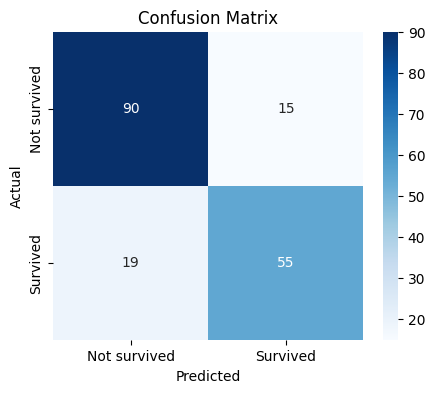

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
# Predict on the test set 
y_pred = model_0.predict(X_test)

# Plot a confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Not survived", "Survived"], yticklabels=["Not survived", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Classification report (precision, recall, f1-socre)
cr = classification_report(y_test, y_pred)
print("Classification Report:")
print(cr)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



c:\Users\didio\AppData\Local\Programs\Python\Python312\Lib\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


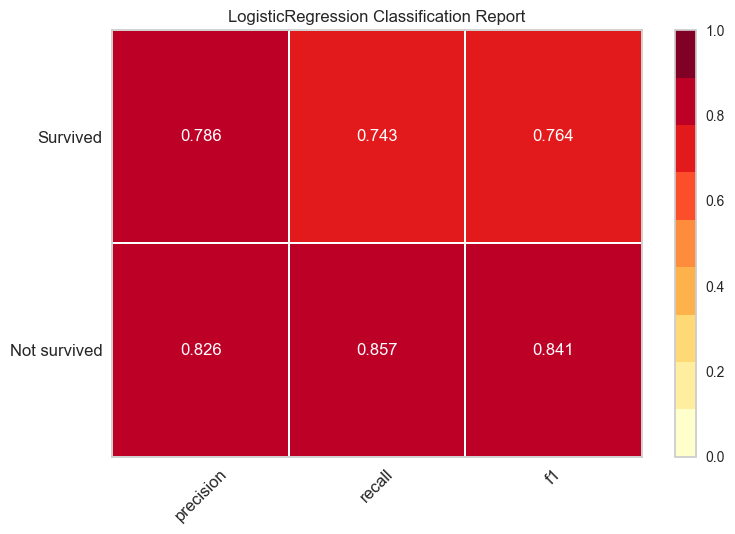

<Axes: title={'center': 'LogisticRegression Classification Report'}>

In [ ]:
# Visualize the classification report using yellowbrick
from yellowbrick.classifier import ClassificationReport

visualizer = ClassificationReport(model_0, classes=["Not survived", "Survived"])
visualizer.score(X_test, y_test)
visualizer.show()

## 3.0 Predict survival using the test.cvs data

In [ ]:
# load test data 
test_df = pd.read_csv("test.csv")
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
print(test_df.isnull().sum())
print(df.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_female     0
Sex_male       0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64


### 3.1 Process test data

In [ ]:
# Process data
test_df["Age"] = test_df["Age"].fillna(df["Age"].median())
test_df["Fare"] = test_df["Fare"].fillna(df["Fare"].median())
test_df = pd.get_dummies(test_df, columns=["Sex", "Embarked"])

# Ensure all columns match training data
for col in X_train.columns:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[X_train.columns]



### 3.2 predict in test data

In [ ]:
test_pred = model_0.predict(test_df)

# 4. Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': pd.read_csv("test.csv")['PassengerId'],
    'Survived': test_pred
})

# 5. Save to CSV
submission.to_csv("submission.csv", index=False)

C:\Users\didio\AppData\Local\Temp\ipykernel_102680\3325249123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_pred, palette="Blues")


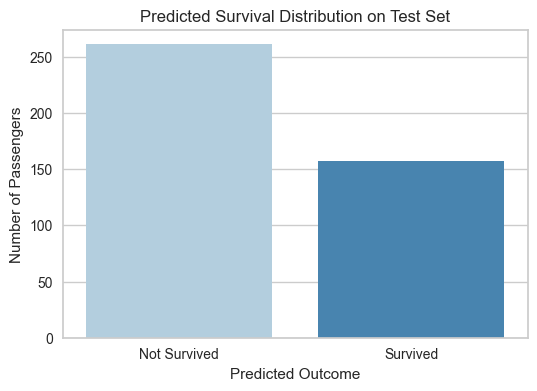

In [ ]:
# Plot the count of predicted survivors (1) and non-survivors (0)
plt.figure(figsize=(6,4))
sns.countplot(x=test_pred, palette="Blues")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.xlabel("Predicted Outcome")
plt.ylabel("Number of Passengers")
plt.title("Predicted Survival Distribution on Test Set")
plt.show()

# 4.0 Decision tree model

## 4.1 Exploring data


In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

## 4.2 Cleaning data

In [3]:
# Drop cabin bc of too many missing values
df = df.drop("Cabin", axis=1)

# Fill missing ages with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [4]:
print(df.isnull().sum())
df.head()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [5]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})
df = pd.get_dummies(df, columns=["Embarked"])

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,False,True


## 4.3 Creating new features that can be helpfull on classification

In [7]:
# Extract title from name
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# See the most common titles
print(df["Title"].value_counts())

# Group rare titles as "other"
rare_titles = ["Lady", "Cuntess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
df["Title"] = df["Title"].replace(rare_titles, "Other")

# Map common titles to numbers
title_mapping = {"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Other": 4}
df["Title"] = df["Title"].map(title_mapping)

df.head()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\didio\AppData\Local\Temp\ipykernel_37136\676648449.py:2: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,False,True,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,True,False,False,2.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,False,True,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,False,True,2.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,False,True,0.0


In [8]:
print(df["Title"].value_counts().sum())
print(df["Name"].value_counts().sum())

886
891


## 4.4 Split data between train and test

In [9]:
X = df.drop(["Survived", "Name", "Ticket", "PassengerId"], axis=1)
y = df["Survived"]

In [10]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,3,0,22.0,1,0,7.2500,False,False,True,0.0
1,1,1,38.0,1,0,71.2833,True,False,False,2.0
2,3,1,26.0,0,0,7.9250,False,False,True,1.0
3,1,1,35.0,1,0,53.1000,False,False,True,2.0
4,3,0,35.0,0,0,8.0500,False,False,True,0.0


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
331,1,0,45.5,0,0,28.5000,False,False,True,0.0
733,2,0,23.0,0,0,13.0000,False,False,True,0.0
382,3,0,32.0,0,0,7.9250,False,False,True,0.0
704,3,0,26.0,1,0,7.8542,False,False,True,0.0
813,3,1,6.0,4,2,31.2750,False,False,True,1.0


## 4.5 Build and train the model

In [13]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 4.6 Plot and evaluate the model

In [22]:
from sklearn.metrics import accuracy_score

# Predict on train & test
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Train accuracy: 0.9817415730337079
Test accuracy: 0.770949720670391


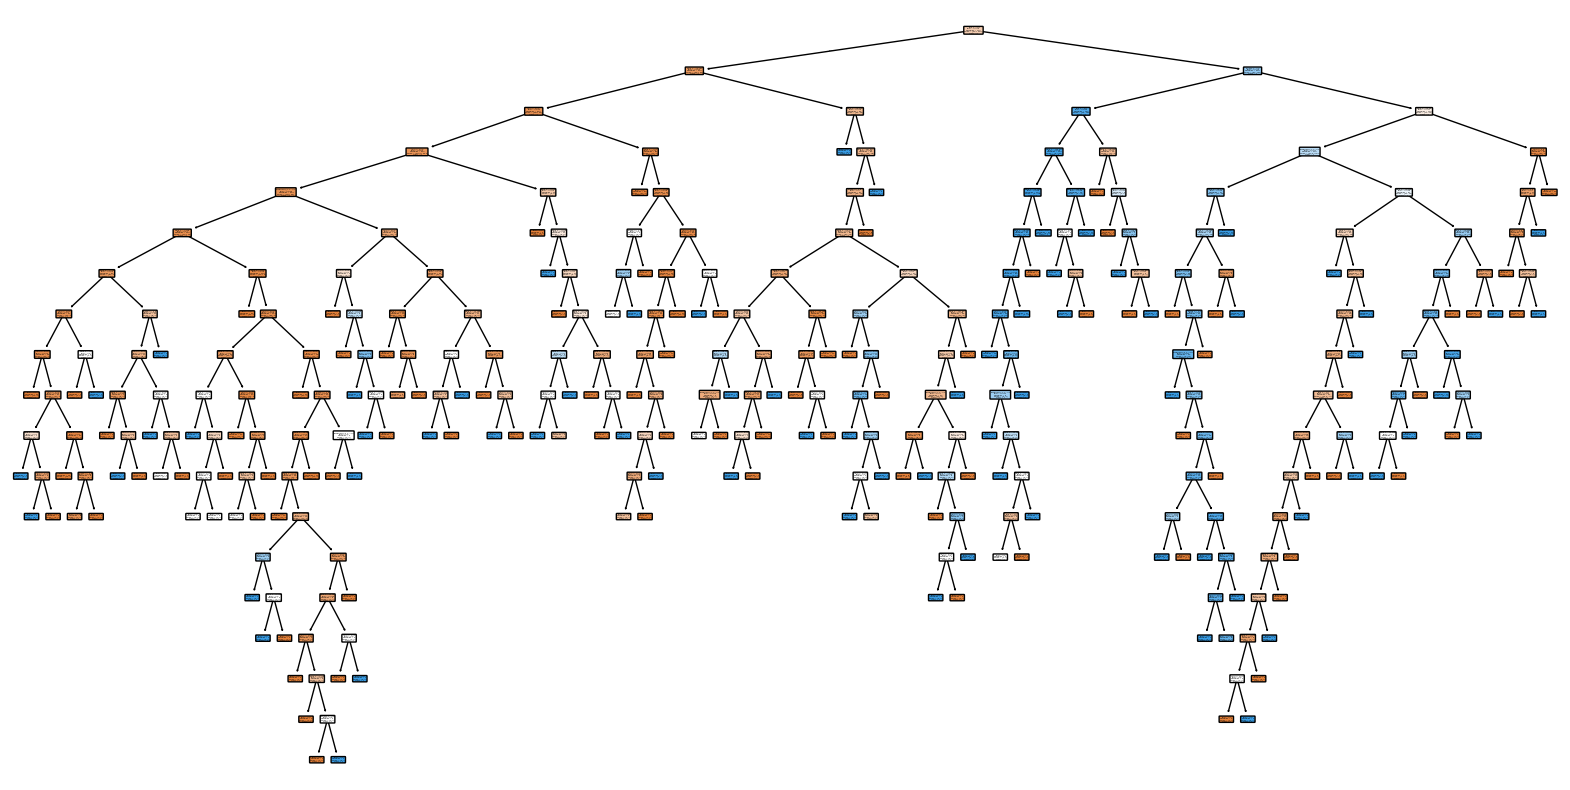

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=X_train.columns,
          class_names=[str(cls) for cls in dt_model.classes_],
          filled=True,
          rounded=True)
plt.show()

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X_train.columns,
    class_names=[str(cls) for cls in dt_model.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

In [17]:
import pandas as pd

feature_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))


Title         0.355361
Fare          0.319981
Age           0.174372
Pclass        0.096731
Parch         0.018777
SibSp         0.014104
Embarked_C    0.008167
Embarked_S    0.007450
Embarked_Q    0.005056
Sex           0.000000
dtype: float64


## 4.7 Improve model


### 4.8 Creat and train dt_model_1 

In [18]:
dt_model_1 = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="entropy"
)

dt_model_1.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.9 Evaluate and plot dt_model_1

In [23]:
from sklearn.metrics import accuracy_score

# Predict on train & test
y_train_pred = dt_model_1.predict(X_train)
y_test_pred = dt_model_1.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Train accuracy: 0.8370786516853933
Test accuracy: 0.8212290502793296


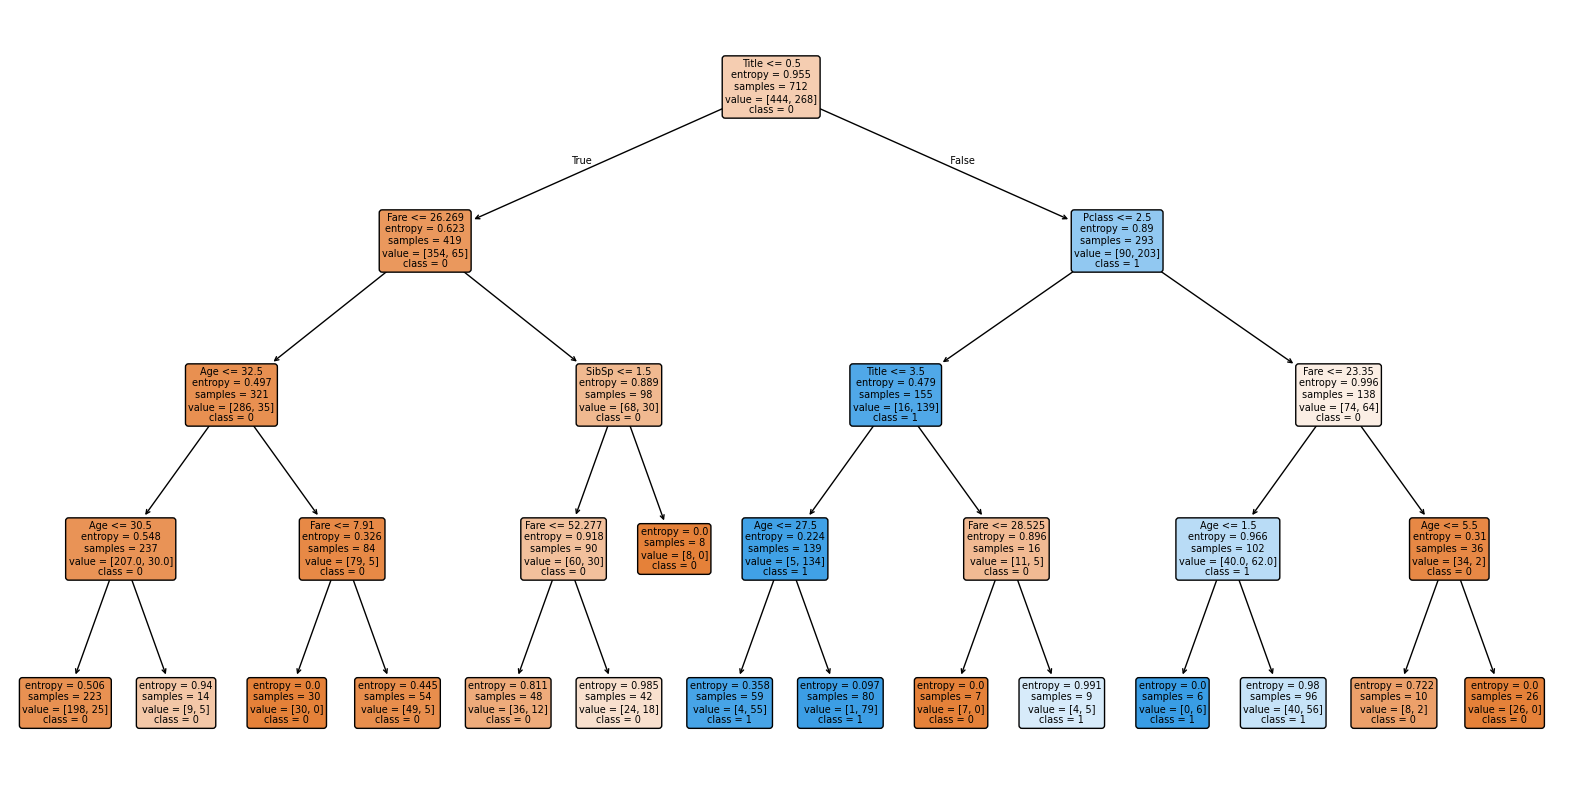

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model_1,
          feature_names=X_train.columns,
          class_names=[str(cls) for cls in dt_model.classes_],
          filled=True,
          rounded=True)
plt.show()

In [21]:
import pandas as pd

feature_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))

Title         0.355361
Fare          0.319981
Age           0.174372
Pclass        0.096731
Parch         0.018777
SibSp         0.014104
Embarked_C    0.008167
Embarked_S    0.007450
Embarked_Q    0.005056
Sex           0.000000
dtype: float64


## 5.0 Improve model with GridSearchCV

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid (reasonable values for data)
param_grid ={
    "max_depth": [3, 4, 5, 6], # not too deep -> Keeps model simple 
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 5, 8],
    "criterion": ["gini", "entropy"]
}

# Creat model_2
dt_model_2 = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation
grid = GridSearchCV(
    dt_model_2,
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Fit on training data
grid.fit(X_train, y_train)

print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation accuracy: {grid.best_score_:.2f}")

Best parameters found: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 15}
Best cross-validation accuracy: 0.83


### 5.1 Evaluate and plot best model


In [29]:
from sklearn.metrics import accuracy_score

# Predict using best estimator found
best_dt = grid.best_estimator_

y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)


print(f"Train accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred)}")

Train accuracy: 0.8426966292134831
Test accuracy: 0.8324022346368715


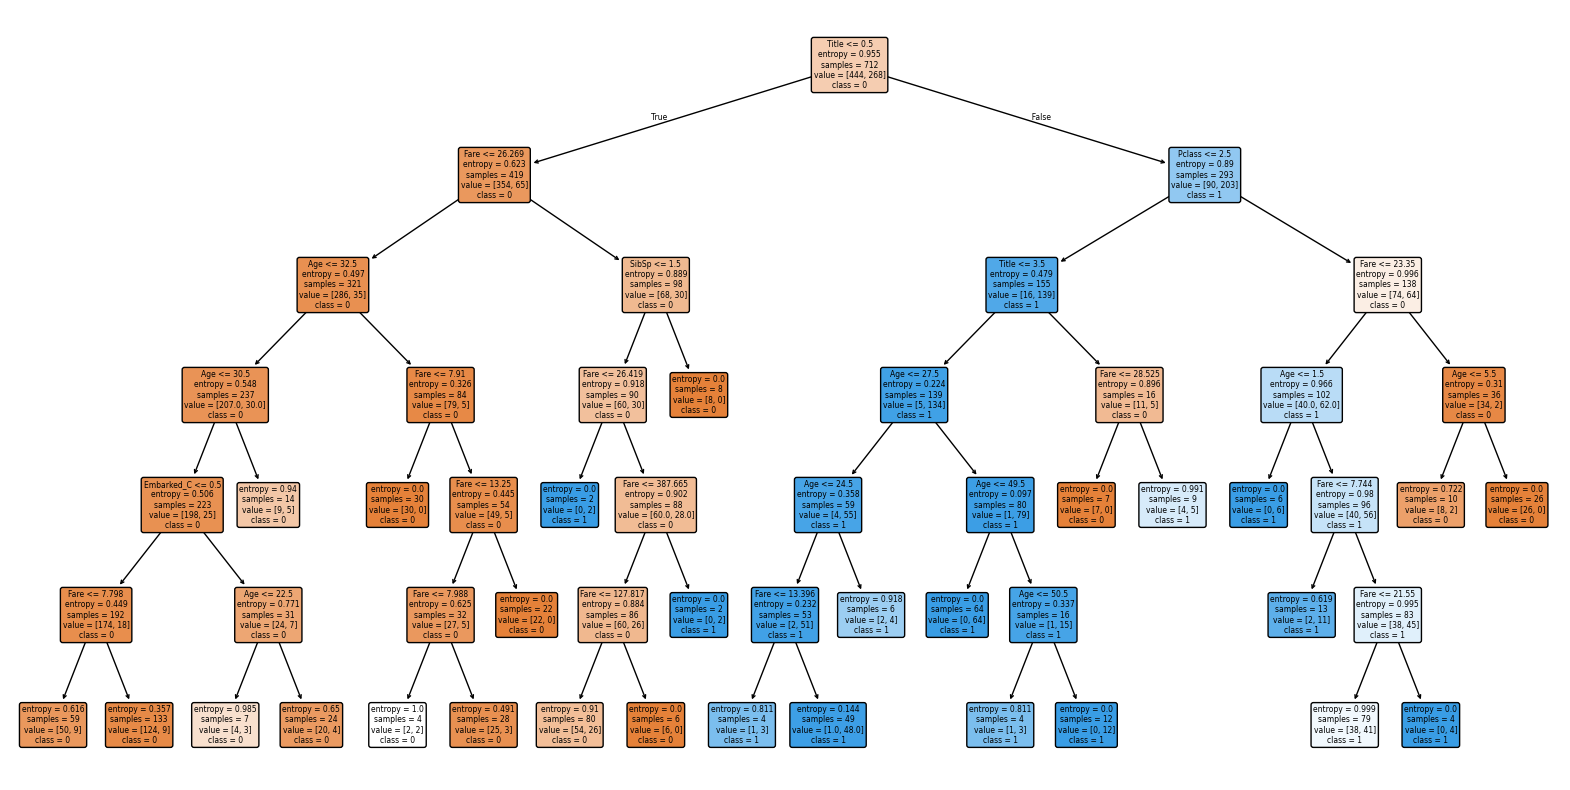

Title         0.538879
Fare          0.224942
Pclass        0.140742
Age           0.074577
SibSp         0.012758
Embarked_C    0.008102
Sex           0.000000
Parch         0.000000
Embarked_Q    0.000000
Embarked_S    0.000000
dtype: float64


In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(best_dt,
          feature_names=X_train.columns,
          class_names=[str(cls) for cls in best_dt.classes_],
          filled=True, rounded=True)
plt.show()

# Feature importance
import pandas as pd

feat_importance = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance)


## 5.2 Predict on test data and creat file for submissions

In [31]:
import pandas as pd

test_df = pd.read_csv("test.csv")


In [33]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### 5.3 Clean data

In [40]:
# Process data
test_df["Age"] = test_df["Age"].fillna(df["Age"].median())
test_df["Fare"] = test_df["Fare"].fillna(df["Fare"].median())
test_df["Sex"] = test_df["Sex"].map({"male":0, "female":1})
#test_df = pd.get_dummies(test_df, columns=["Embarked"])



In [42]:
# Extract title from name
test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# See the most common titles
print(test_df["Title"].value_counts())

# Group rare titles as "other"
test_rare_titles = ["Lady", "Cuntess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
test_df["Title"] = test_df["Title"].replace(test_rare_titles, "Other")

# Map common titles to numbers
title_mapping = {"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Other": 4}
test_df["Title"] = test_df["Title"].map(title_mapping)


Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\didio\AppData\Local\Temp\ipykernel_37136\2636422249.py:2: SyntaxWarning: invalid escape sequence '\.'
  test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


In [44]:
# Ensure all columns match training data
for col in X_train.columns:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[X_train.columns]

In [45]:
test_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,3,0,34.5,0,0,7.8292,False,True,False,0.0
1,3,1,47.0,1,0,7.0000,False,False,True,2.0
2,2,0,62.0,0,0,9.6875,False,True,False,0.0
3,3,0,27.0,0,0,8.6625,False,False,True,0.0
4,3,1,22.0,1,1,12.2875,False,False,True,2.0


### 5.4 Predict and creat dataframe

In [47]:
kaggle_predictions = best_dt.predict(test_df)

submission = pd.DataFrame({
    "PassengerId":  pd.read_csv("test.csv")['PassengerId'],
    "Survived": kaggle_predictions
})

submission.to_csv("submission_1.csv", index=False)

# 6 Random Forest

## 6.0 Prep data

### 6.1 Understend data

In [2]:
import pandas as pd
train_df = pd.read_csv("train.csv")

print(train_df.info())
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 6.2 Feature engineering

In [4]:
# Extract title using regex
train_df["Title"] = train_df["Name"].str.extract("([A-Za-z]+)\.", expand=False)

# Group rare titles into other 
train_df["Title"] = train_df["Title"].replace(["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"], "Other")
train_df["Title"] = train_df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\didio\AppData\Local\Temp\ipykernel_36208\2772245077.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_df["Title"] = train_df["Name"].str.extract("([A-Za-z]+)\.", expand=False)


In [ ]:
# Creat family size (Can be useful on training)
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

In [7]:
# Create isAlone 
train_df["IsAlone"] = 0
train_df.loc[train_df["FamilySize"] == 1, "IsAlone"] = 1

### 6.3 Cleaning data

In [8]:
# Fill missing age with median
train_df["Age"].fillna(train_df["Age"].median(), inplace=True)

# Fill embarked with most common
train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)

# Transform sex to numbers
train_df["Sex"] = train_df["Sex"].map({"male":0, "female":1})

# Transform embarked to numbers
embarked_dummies = pd.get_dummies(train_df["Embarked"], prefix="Embarked")
train_df = pd.concat([train_df, embarked_dummies], axis=1)

# Map title to numbers
title_mapping = {"Mr":0, "Miss":1, "Mrs":2, "Master":3, "Other":4}
train_df["Title"] = train_df["Title"].map(title_mapping)

C:\Users\didio\AppData\Local\Temp\ipykernel_36208\902232927.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Age"].fillna(train_df["Age"].median(), inplace=True)


## 7.0 Choose final features and split data

In [11]:
features = ["Pclass","Sex","Age","SibSp","Parch","Fare","FamilySize","IsAlone","Title","Embarked_C","Embarked_Q","Embarked_S"]

X = train_df[features]
y = train_df["Survived"]

In [12]:
from sklearn.model_selection import train_test_split
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8.0 Creat RF_model_0

In [13]:
from sklearn.ensemble import RandomForestClassifier

RFModel_0 = RandomForestClassifier(random_state=42)
RFModel_0.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
from sklearn.metrics import accuracy_score

y_train_pred = RFModel_0.predict(X_train)
y_test_pred = RFModel_0.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred)}")

Train accuracy: 0.9817415730337079
Test accuracy: 0.8379888268156425


In [16]:
feature_importance = pd.Series(
    RFModel_0.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Fare          0.247694
Age           0.210052
Title         0.166910
Sex           0.153068
Pclass        0.077732
FamilySize    0.046581
SibSp         0.029723
Parch         0.021356
Embarked_C    0.015045
Embarked_S    0.014214
IsAlone       0.010180
Embarked_Q    0.007443
dtype: float64


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {"n_estimators": [100,200,300],
              "max_depth": [4,6,8,None],
              "min_samples_split": [2,5,10],
              "min_samples_leaf":[1,2,5],
              "max_features": ["sqrt", "log2",None]}

In [19]:
RFModel_1 = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=RFModel_1,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [20]:
grid_search.fit(X_train, y_train)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [21]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters found: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy: 0.832817886339013


In [22]:
best_rf = grid_search.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Train accuracy: 0.9073033707865169
Test accuracy: 0.8324022346368715


## 9.0 Improve model with more feature engineering

In [23]:
# Already have FamilySize
train_df['FamilySizeBin'] = pd.cut(
    train_df['FamilySize'],
    bins=[0,1,4,8,11],  # example bins: alone, small family, medium, large
    labels=[0,1,2,3]
).astype(int)


train_df['FareBin'] = pd.qcut(
    train_df['Fare'],
    4,            # quartiles → 4 bins
    labels=[0,1,2,3]
).astype(int)

train_df['AgeBin'] = pd.cut(
    train_df['Age'],
    bins=[0,12,20,40,120],        # child, teen, adult, older adult
    labels=[0,1,2,3]
).astype(int)

train_df['HasCabin'] = train_df['Cabin'].notnull().astype(int)

train_df['CabinLetter'] = train_df['Cabin'].astype(str).str[0]
# map letters to numbers, unknown to 0
cabin_mapping = {letter:idx+1 for idx, letter in enumerate(sorted(train_df['CabinLetter'].unique()))}
train_df['CabinLetter'] = train_df['CabinLetter'].map(cabin_mapping).fillna(0).astype(int)



In [24]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,FamilySizeBin,FareBin,AgeBin,HasCabin,CabinLetter
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,2,0,False,False,True,1,0,2,0,9
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,2,0,True,False,False,1,3,2,1,3
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,1,1,False,False,True,0,1,2,0,9
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,2,0,False,False,True,1,3,2,1,3
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,1,False,False,True,0,1,2,0,9


In [25]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'FamilySize', 'IsAlone', 'Title',
            'Embarked_C', 'Embarked_Q', 'Embarked_S',
            'FamilySizeBin', 'FareBin', 'AgeBin', 'HasCabin', 'CabinLetter']
X = train_df[features]
y = train_df['Survived']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,    # number of trees
    learning_rate=0.1,   # how much each tree corrects
    max_depth=3,         # shallow trees → generalize better
    random_state=42
)

gb_model.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [28]:
from sklearn.metrics import accuracy_score

y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Train accuracy: 0.9157303370786517
Test accuracy: 0.8435754189944135


In [29]:
import pandas as pd

feat_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance)


Title            0.490050
Fare             0.169182
Pclass           0.124326
Age              0.071862
CabinLetter      0.051936
FamilySizeBin    0.028446
Sex              0.018865
FamilySize       0.016184
Embarked_S       0.008223
FareBin          0.006831
Embarked_Q       0.003885
Embarked_C       0.003156
SibSp            0.002890
AgeBin           0.002887
Parch            0.001065
IsAlone          0.000211
HasCabin         0.000000
dtype: float64


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,    # number of trees
    learning_rate=0.1,   # how much each tree corrects previous ones
    max_depth=3,         # shallow trees to generalize better
    random_state=42,
    use_label_encoder=False,  # suppresses warning
    eval_metric='logloss'    # required in newer XGBoost
)

xgb_model.fit(X_train, y_train)


c:\Users\didio\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:47:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [31]:
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)


In [32]:
from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Train accuracy: 0.8918539325842697
Test accuracy: 0.8324022346368715


In [33]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}


In [34]:
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',  # optimize for accuracy
    cv=5,                # 5-fold cross-validation
    n_jobs=-1            # use all CPU cores
)


In [35]:
grid_search.fit(X_train, y_train)


c:\Users\didio\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:49:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [36]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation accuracy: 0.8412784398699891


In [37]:
best_xgb = grid_search.best_estimator_

y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Train accuracy: 0.9002808988764045
Test accuracy: 0.8324022346368715


## Submission

In [63]:
test_df = pd.read_csv("test.csv")


In [64]:
# Example:
# Fill missing age with median
test_df["Age"].fillna(train_df["Age"].median(), inplace=True)

test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)


# Fill embarked with most common
test_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)

test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Title'].replace(title_mapping)  # same title mapping

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

test_df['FamilySizeBin'] = pd.cut(test_df['FamilySize'], bins=[0,1,4,8,11], labels=[0,1,2,3]).astype(int)
test_df['FareBin'] = pd.qcut(test_df['Fare'].fillna(test_df['Fare'].median()), 4, labels=[0,1,2,3]).astype(int)
test_df['AgeBin'] = pd.cut(test_df['Age'].fillna(test_df['Age'].median()), bins=[0,12,20,40,120], labels=[0,1,2,3]).astype(int)

test_df['HasCabin'] = test_df['Cabin'].notnull().astype(int)
test_df['CabinLetter'] = test_df['Cabin'].astype(str).str[0].map(cabin_mapping).fillna(0).astype(int)

# Encode Sex
test_df['Sex'] = test_df['Sex'].map({'male':0, 'female':1}).astype(int)

# One-hot Embarked (some passengers may not have Embarked info)
test_df['Embarked_C'] = (test_df['Embarked'] == 'C').astype(int)
test_df['Embarked_Q'] = (test_df['Embarked'] == 'Q').astype(int)
test_df['Embarked_S'] = (test_df['Embarked'] == 'S').astype(int)

test_df['Title'] = test_df['Title'].map(title_mapping).fillna(4).astype(int)



<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
C:\Users\didio\AppData\Local\Temp\ipykernel_36208\3189558400.py:11: SyntaxWarning: invalid escape sequence '\.'
  test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\didio\AppData\Local\Temp\ipykernel_36208\3189558400.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["Age"].fillna(train_df["Age"].median(), inplace=True)
C:\Users\didio\AppData\Local\Temp\ipykernel_36208\3189558400.p

In [65]:
X_submission = test_df[features]  # `features` list you used for training


In [66]:
X_submission.isnull().sum()

Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
FamilySize       0
IsAlone          0
Title            0
Embarked_C       0
Embarked_Q       0
Embarked_S       0
FamilySizeBin    0
FareBin          0
AgeBin           0
HasCabin         0
CabinLetter      0
dtype: int64

In [67]:
predictions_2 = best_xgb.predict(X_submission)
predictions_3 = gb_model.predict(X_submission)


In [68]:
submission_2 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions_2
})

submission_3 = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions_3
})


In [69]:
submission_2.to_csv("submission_2.csv", index=False)
submission_3.to_csv("submission_3.csv", index=False)
